# ASTRAL Visualizations

In [130]:
# sys libraries
import os
from pathlib import Path

# Data-science libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# MSC Simulation libraries
import dendropy
from dendropy.simulate import treesim
from dendropy import Tree, TreeList

# Set plotting style and working directories
sns.set_theme()
sns.set_style('whitegrid')

workdir = os.environ.get('WORKDIR')

# change to current working directory
os.chdir(workdir)

base_dir = Path(workdir)
figures_dir = base_dir / "figures"

print(f'Current work directory is {workdir}')

Current work directory is /usr/jovyan/bipartition_covers


## Helper Functions

Here we develop some helper functions we will use throughout the remainder of the notebook.

First, since it is the basis of all our bounds we want to develop an efficient implementation of calculating:

$$g_{ij}(T) := \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}j_{(k-1)} i_{[k]}}{j!(k-j)!i_{(k)}}$$

Here $a_{(k)} = a(a+1) \cdot ... \cdot (a+k-1)$ and $a_{[k]} = a(a-1)\cdot ... \cdot (a-k+1)$ denote the rising and falling factorial respectively. Rather than recalculating the factorials at every step we want to calculate them iteratively to save some time and avoid potential integer overflows. Note that:

$$g_{ij}(T) = \sum_{k=j}^i \frac{e^{-{k \choose 2}T} (2k-1)(-1)^{k-j}}{j!} \cdot \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}}$$

The second term can be re-written as:

$$c_k := \frac{j_{(k-1)} i_{[k]}}{(k-j)!i_{(k)}} = \left(\prod_{m=1}^{k-j} \frac{1}{m}\right)\left(\prod_{m=0}^{k-2} (j+m)\right)\left(\prod_{m=0}^{k-1} \frac{i-m}{i+m}\right)$$

In particular:

$$\frac{c_{k+1}}{c_k} = \frac{k+j-1}{k-j+1} \cdot \frac{i-k}{i+k}$$

Thus we can calculate $c_j$ for the first term using the above formula, and iteratively update it to get future values of $c_k$.


In [131]:
from utility.coalescent_probabilities import g_ij

### Plotting $g_{ij}(T)$

Here, we start by plotting our function $g_{ij}(T)$. 

In [132]:
from utility.plotting import plot_multiple_T_values

Comparing different T values for j=1


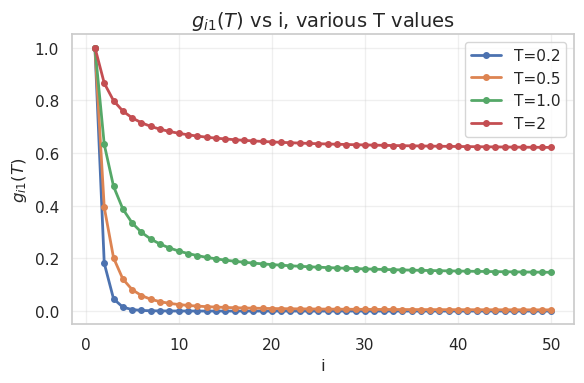

Plot saved to: /usr/jovyan/bipartition_covers/figures/g_i1_plot


In [133]:
j = 1
T_values = [0.2, 0.5, 1.0, 2]
print(f"Comparing different T values for j={j}")
plot_multiple_T_values(j, T_values, max_i=50, savepath=figures_dir / "g_i1_plot")

## Building Our Bounds

In the following sections we explore the various bounds we have developed throughout our work. 

In [134]:
from utility.bounds import original_bound, caterpillar_bound, one_step_bound, balanced_bound
from utility.plotting import plot_bound

In [135]:
T_vals = [0.1, 0.2, 0.5, 1, 2]
k_vals = range(5, 35, 5)
q = 0.99
log_plot=True
figsize=(12,4)

### Original Bound

The original paper produced a bound of the form:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\log\left(1-g_{k-2,1}(T_{min}) \right)}$$

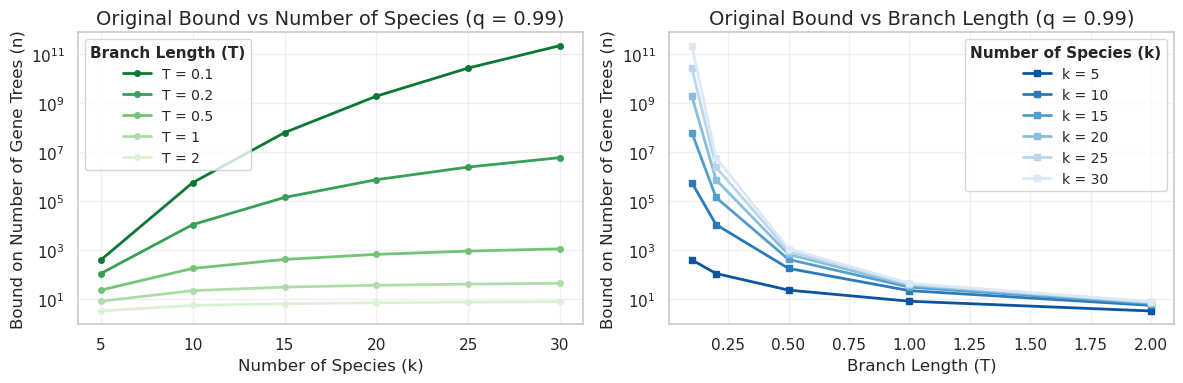

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/original_bound.png


In [136]:
save_path = figures_dir / 'bound_plots' / 'original_bound.png'
bound_name = 'Original'
_ = plot_bound(original_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 1: Caterpillar Trees

My first new bound:

$$n \geq \frac{\log\left(\frac{1-q}{k-3} \right)}{\frac{1}{k-3}\sum_{\ell=2}^{k-2}\log\left(1-g_{\ell,1}(T_{min}) \right)}$$

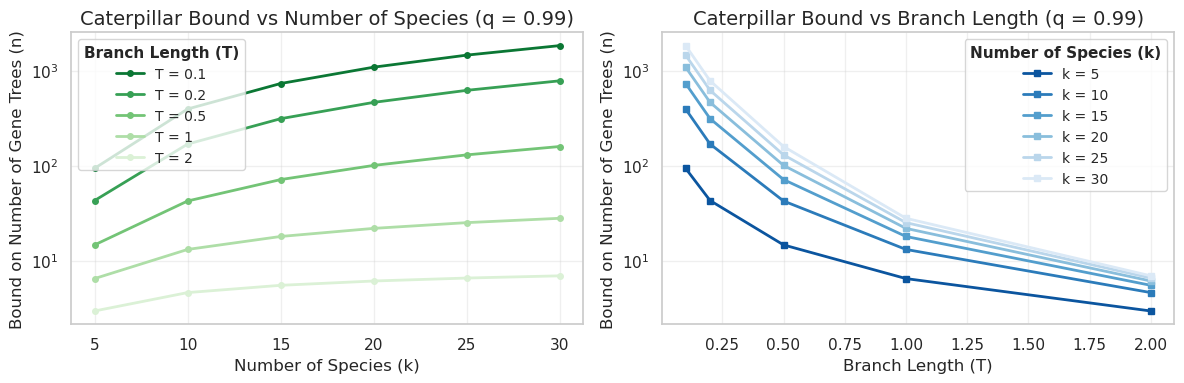

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/caterpillar_bound.png


In [137]:
save_path = figures_dir / 'bound_plots' / 'caterpillar_bound.png'
bound_name = 'Caterpillar'
_ = plot_bound(caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 2: Coalescents One-Step Down

By considering coalescent events occuring one-step below the current edge, we were able to improve the bound to:

$$ n \geq \frac{\log\left(\frac{1-q}{k-3}\right)}{\frac{1}{k-3} \sum_{\ell = 2}^{k-2}\log \left(1-q_{\ell}\right)}$$

 where for $m(\ell) := \lfloor \ell / 2\rfloor$ we define:

 $$ q_\ell := \sum_{r=1}^{m(\ell)} \sum_{s=1}^{\ell-m(\ell)} g_{m(\ell),r}(T_{min}) \cdot g_{\ell-m(\ell), s}(T_{min}) \cdot g_{r+s, 1}(T_{min})$$


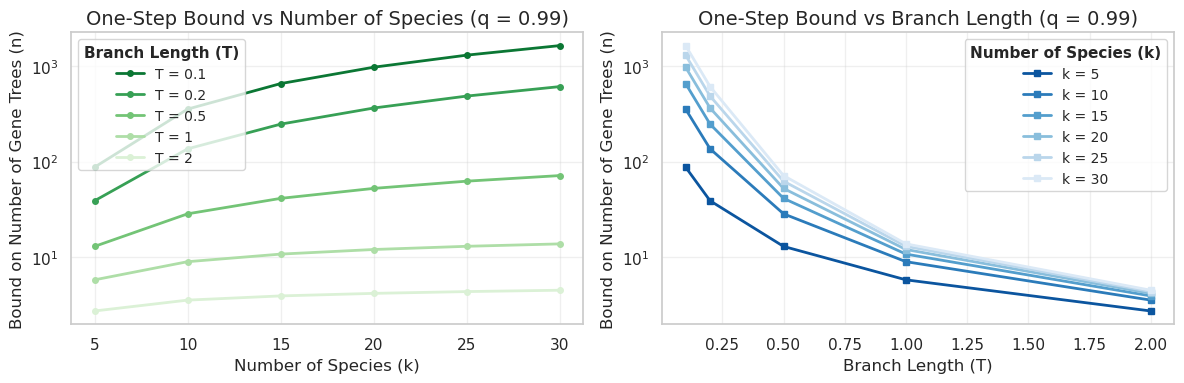

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/one_step_bound.png


In [138]:
save_path = figures_dir / 'bound_plots' / 'one_step_bound.png'
bound_name = 'One-Step'
_ = plot_bound(one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

### Improved Bound 3: Balanced Trees

$$n \geq \frac{\log\left(\frac{1-q}{k-3}\right)}{\frac{1}{k-3} \sum_{\ell = 2}^{k-2}\log \left(1-z_{\ell}\right)}$$

where $z_\ell := \mathbb{P}(Z_{\ell} = 1)$ and where the distributions of $Z_\ell$ are defined recursively as:

$$\mathbb{P}(Z_\ell = j) = g_{Z_{\lceil \ell/2\rceil} + Z_{\lfloor \ell/2\rfloor}', j} (T_{min}) \qquad Z_1 \equiv 1$$

|Here $Z_i'$ is an iid copy of $Z_i$ and $T_{min}$ is the minimum branch length (in coalescent units) in the species tree.

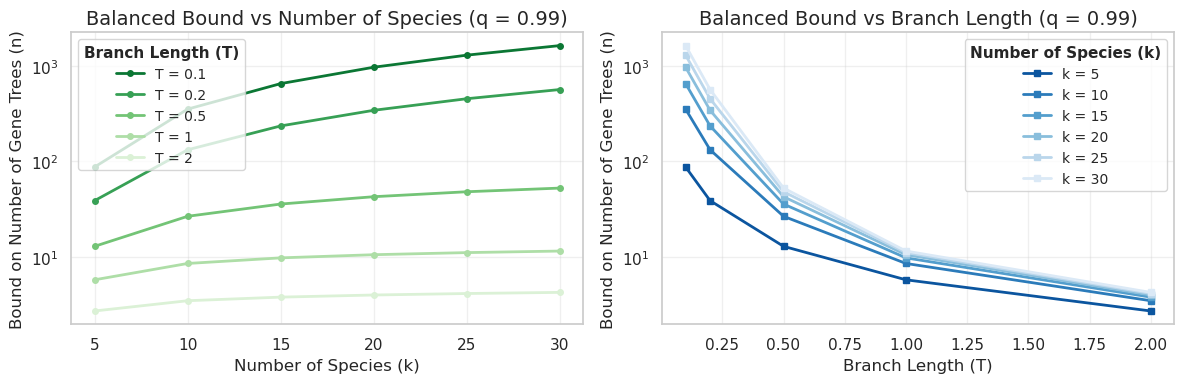

Plot saved to: /usr/jovyan/bipartition_covers/figures/bound_plots/balanced_bound.png


In [139]:
save_path = figures_dir / 'bound_plots' / 'balanced_bound.png'
bound_name = 'Balanced'
_ = plot_bound(balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, bound_name=bound_name)

## Improvement Ratios

In the following section, we compare the relative performances of our bounds.

In [140]:
from utility.plotting import plot_improvement_ratio

In [141]:
# T_vals = [0.1, 0.2, 0.5, 1, 2]
# k_vals = range(5, 35, 5)
# q = 0.99
# log_plot=True
# figsize=(7,4)

### New bounds Versus Old Bounds

##### Caterpillar Bound vs Original

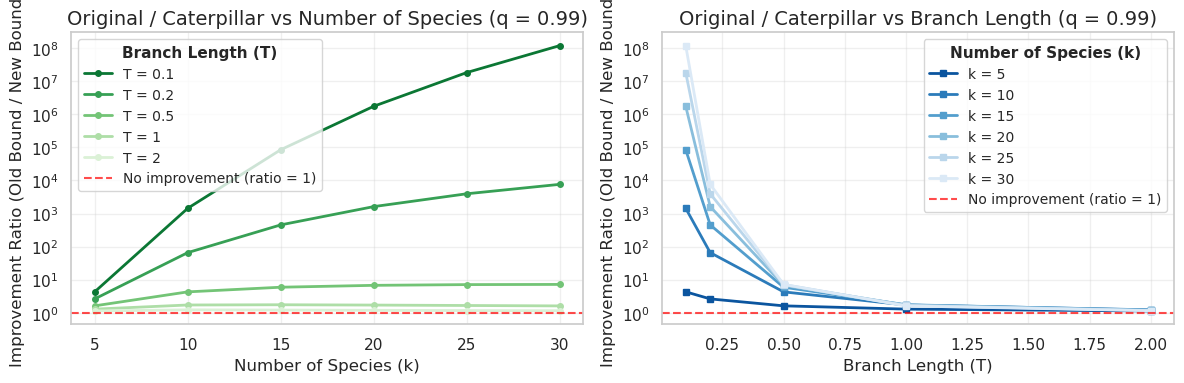

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/cat_vs_original.png


In [142]:
save_path = figures_dir / 'improvement_ratios' / 'cat_vs_original.png'
old_name = 'Original'
new_name = 'Caterpillar'
plot_improvement_ratio(original_bound, caterpillar_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### One-Step Bound vs Original

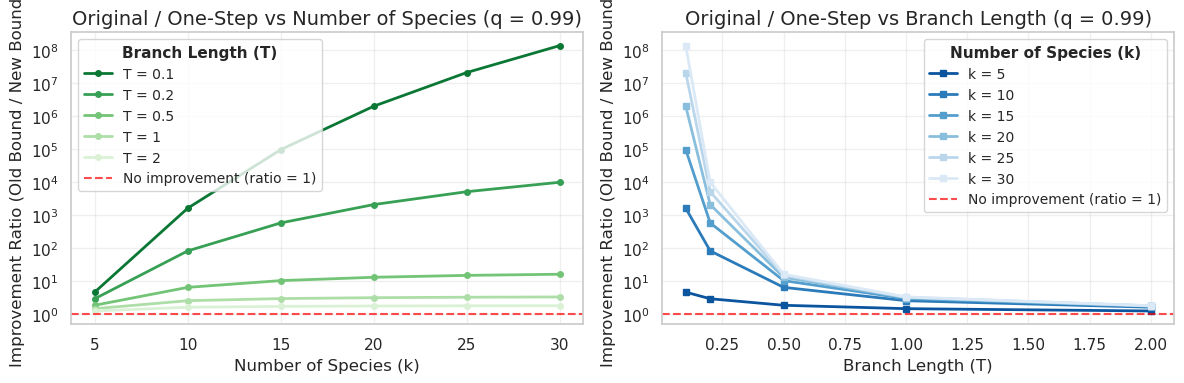

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/onestep_vs_original.png


In [143]:
save_path = figures_dir / 'improvement_ratios' / 'onestep_vs_original.png'
old_name = 'Original'
new_name = 'One-Step'
plot_improvement_ratio(original_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs Original

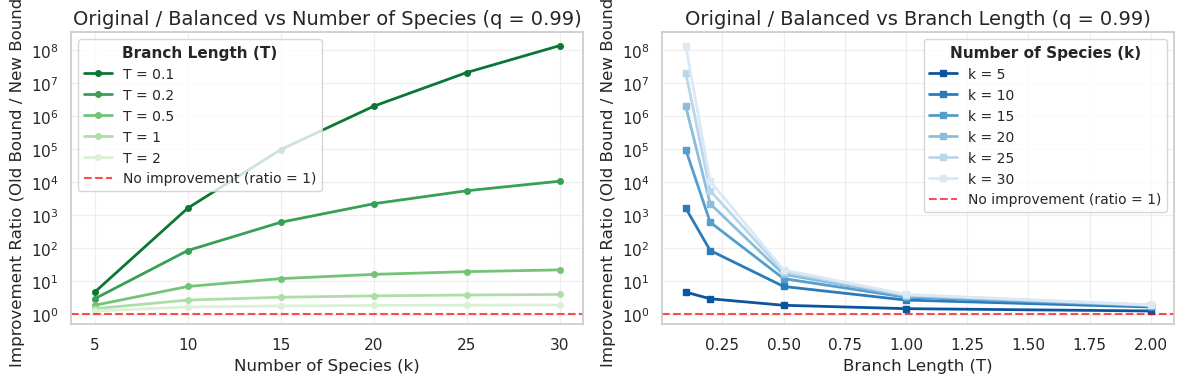

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/balanced_vs_original.png


In [144]:
save_path = figures_dir / 'improvement_ratios' / 'balanced_vs_original.png'
old_name = 'Original'
new_name = 'Balanced'
plot_improvement_ratio(original_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize,  savepath=save_path, old_name=old_name, new_name=new_name)

### New Versus New

##### Caterpillar vs One-Step

Theoretically the one-step bound should be no larger than the caterpillar bound, but let's check to what level it makes an actual improvement over the caterpillar bound. 

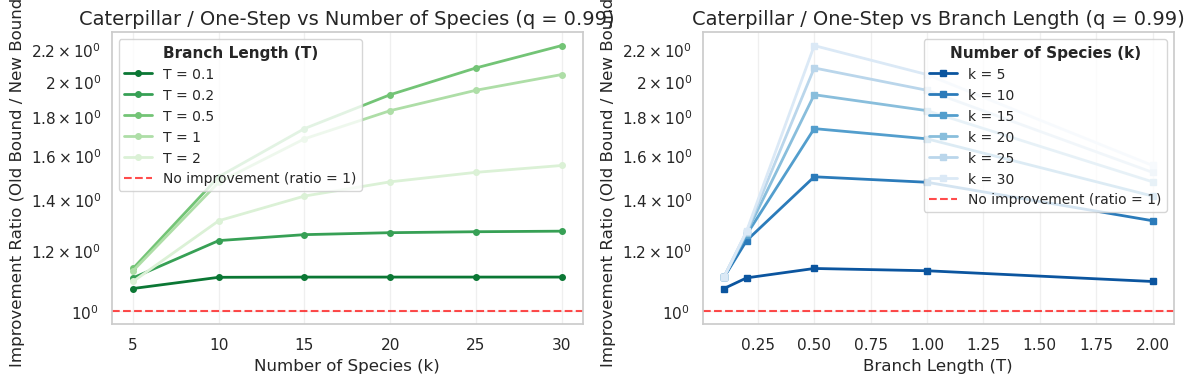

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/one_step_vs_caterpillar.png


In [145]:
save_path = figures_dir / 'improvement_ratios' / 'one_step_vs_caterpillar.png'
old_name = 'Caterpillar'
new_name = 'One-Step'
plot_improvement_ratio(caterpillar_bound, one_step_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

##### Balanced vs One-Step

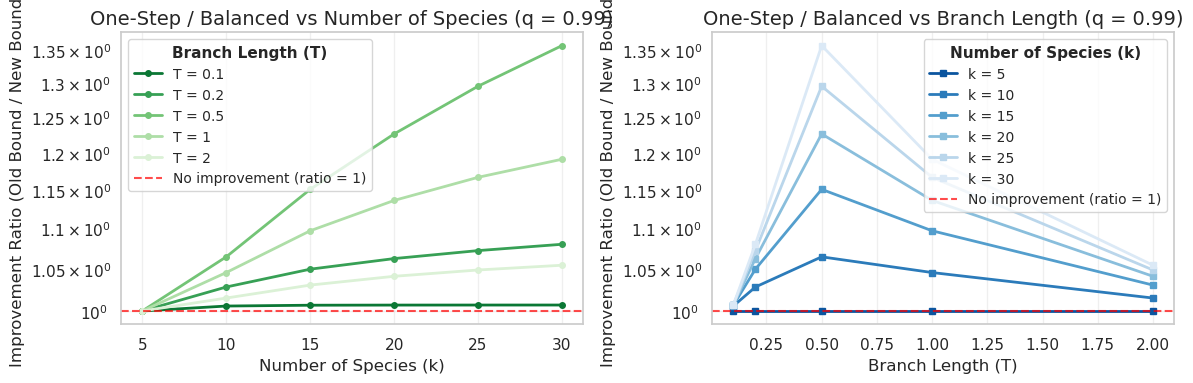

Plot saved to: /usr/jovyan/bipartition_covers/figures/improvement_ratios/balanced_vs_one_step.png


In [146]:
save_path = figures_dir / 'improvement_ratios' / 'balanced_vs_one_step.png'
old_name = 'One-Step'
new_name = 'Balanced'
plot_improvement_ratio(one_step_bound, balanced_bound, T_vals, k_vals, q=q, make_plot=True, log_plot=log_plot, figsize=figsize, savepath=save_path, old_name=old_name, new_name=new_name)

## Gene Tree Simulations

Now we want to explore the empirical behavior of a variety of species tree topologies under the multispecies coalescent model (MSC). In particular, we are interested in studying: for a given species tree, how many gene trees are typically required until we get a bipartition cover of the species tree. We then compare these empirical results to the bounds we developed above to get a sense of how loose those bounds still are.

For this, we utilize the [Dendropy](https://jeetsukumaran.github.io/DendroPy/primer/dataobjects.html) phylogenetic package. In particular, the [Contained Coalescent](https://jeetsukumaran.github.io/DendroPy/primer/treesims.html#multispecies-coalescent-contained-coalescent-or-censored-coalescent-trees) functionality appears to be exactly what we are looking for.
* frequency_of_split: seems like this could help us check for bipartition covers.

Another candidate is [SimPhy](https://pmc.ncbi.nlm.nih.gov/articles/PMC4748750/) which may be useful for larger simulations. 

In [147]:
T_vals = [0.2, 0.5, 2] #1, 0.1 
k_vals = [8, 16]#, 32] #25, 4

num_samples = 1000
max_genes = 10000
q = 0.9
tol = 0.01

##### Tree generation and Sampling

Here we include some code for generating samples from the MSC model under a given species tree topology, and for estimating the bipartition coverage probabilities.

In [19]:
from utility.build_tree_topologies import create_caterpillar_tree, create_balanced_tree, create_yule_tree
from utility.plotting import make_all_overestimation_plots
from utility.msc_sampling import get_T_min

In [20]:
all_bounds = [original_bound, caterpillar_bound, balanced_bound]
names = ['Original', 'Caterpillar', 'Balanced']

### Caterpillar and Balanced Trees

We saw in our paper's analysis that balanced trees and caterpillar trees, where all the branch lengths were equal to $T_{min}$, were in some sense the worst-case when it comes to our bounds. Hence, these are the trees we expect our bounds to be the most tight on.  

##### Caterpillar Tree

In [21]:
num_species = 8
T_min = 1

c_tree = create_caterpillar_tree(num_species, T_min)
print(f'Caterpillar tree (T_min = {get_T_min(c_tree)})')
c_tree.print_plot()

Caterpillar tree (T_min = 1.0)
                                                                 /---------- T0
                                                      /----------+             
                                           /----------+          \---------- T1
                                           |          |                        
                                /----------+          \--------------------- T2
                                |          |                                   
                     /----------+          \-------------------------------- T3
                     |          |                                              
          /----------+          \------------------------------------------- T4
          |          |                                                         
/---------+          \------------------------------------------------------ T5
|         |                                                                    
+        

T_min=2, k=16: 100%|██████████| 6/6 [00:07<00:00,  1.21s/it]  


################################################################################
Results for Original bound
################################################################################


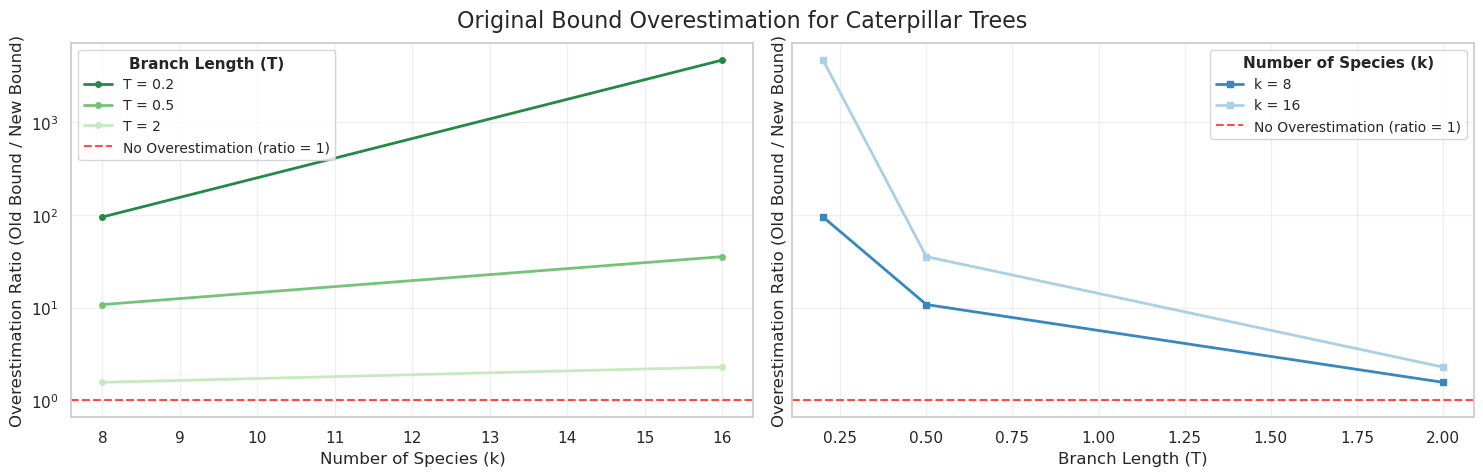

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_original_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_original_bound_vs_q.png


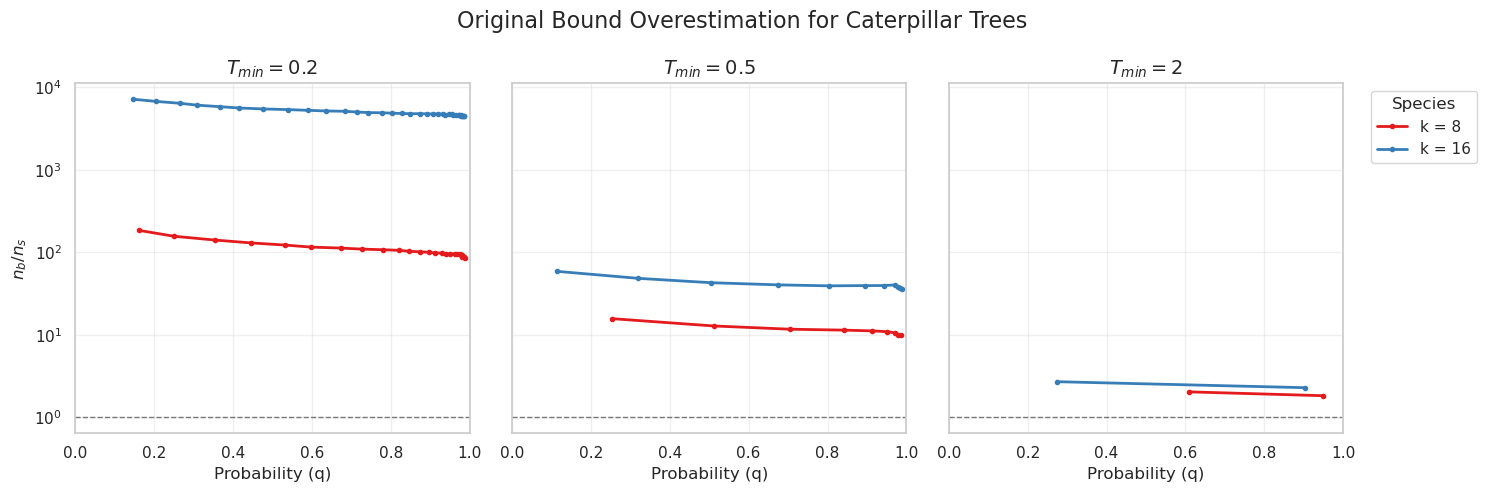

################################################################################
Results for Caterpillar bound
################################################################################


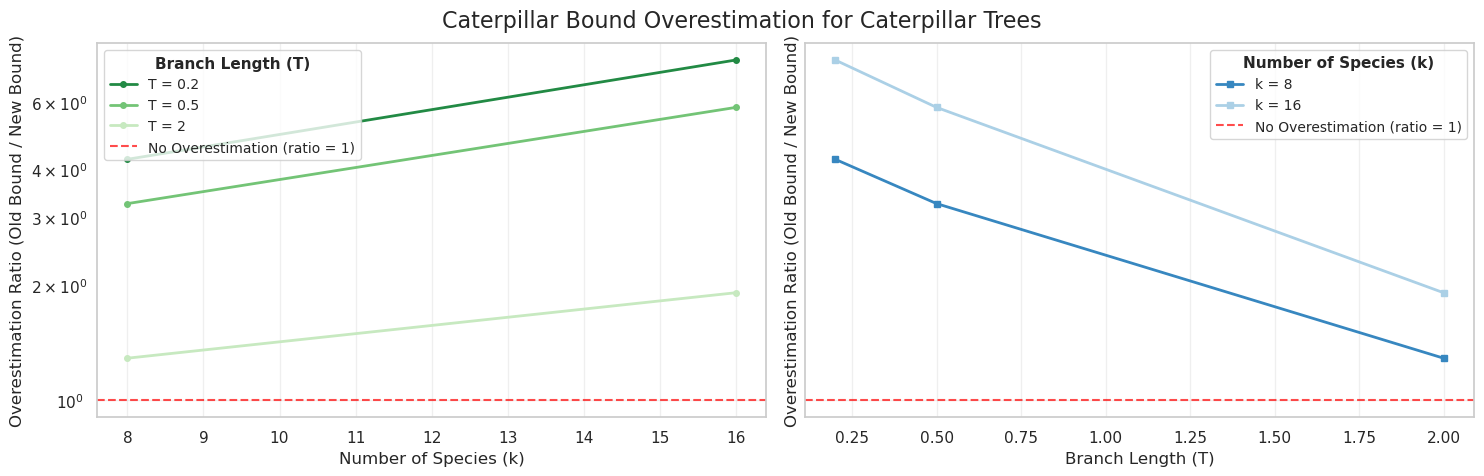

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_caterpillar_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_caterpillar_bound_vs_q.png


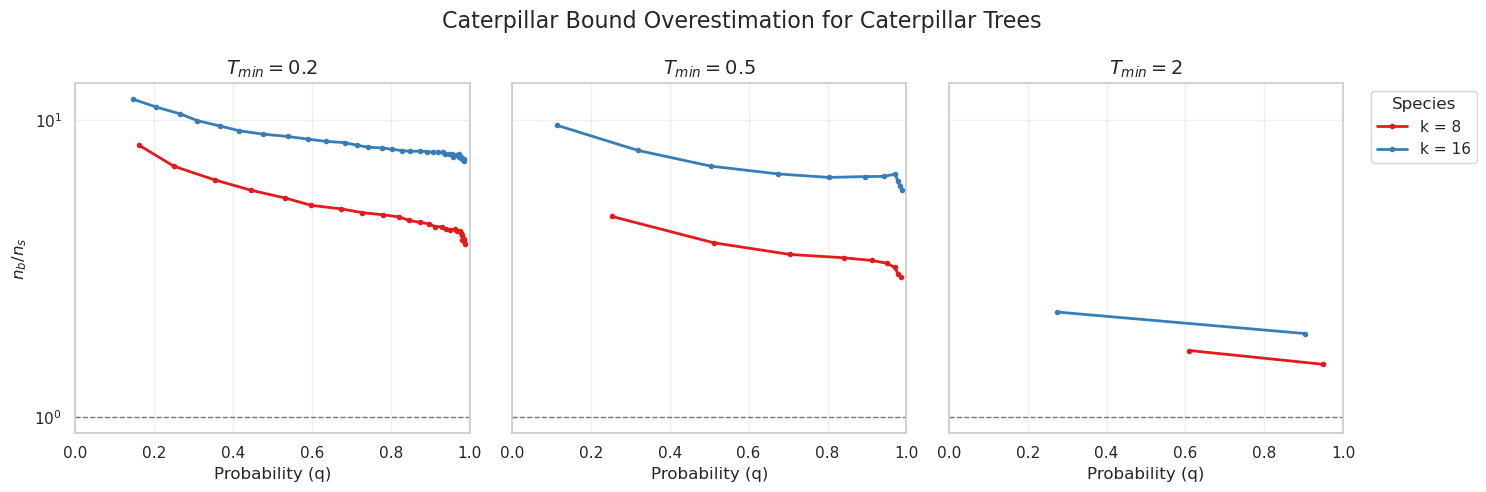

################################################################################
Results for Balanced bound
################################################################################


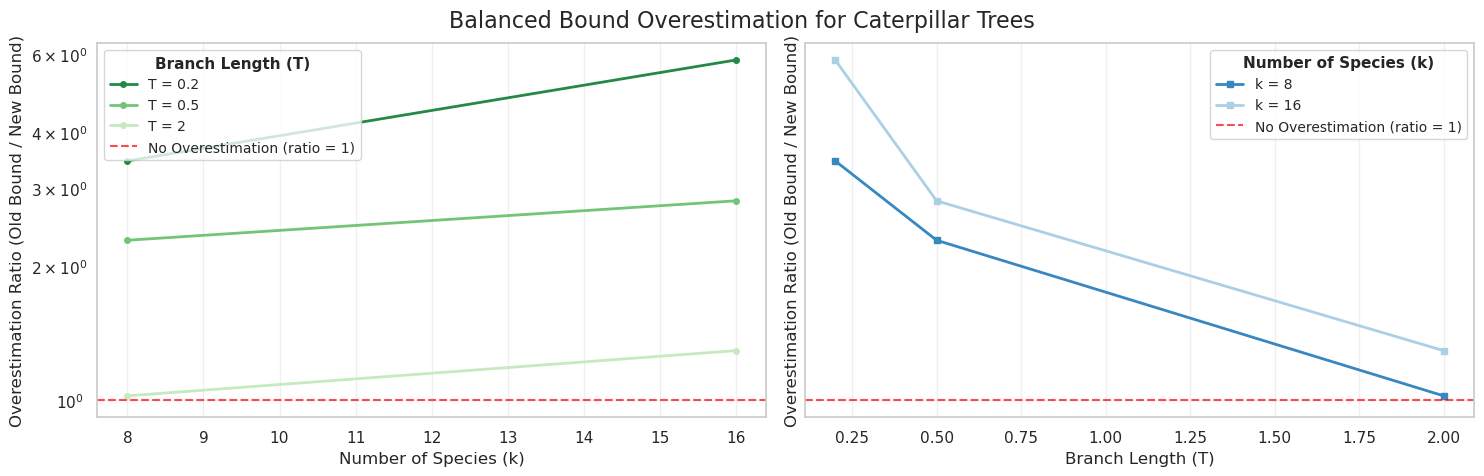

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_balanced_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/caterpillar_tree_balanced_bound_vs_q.png


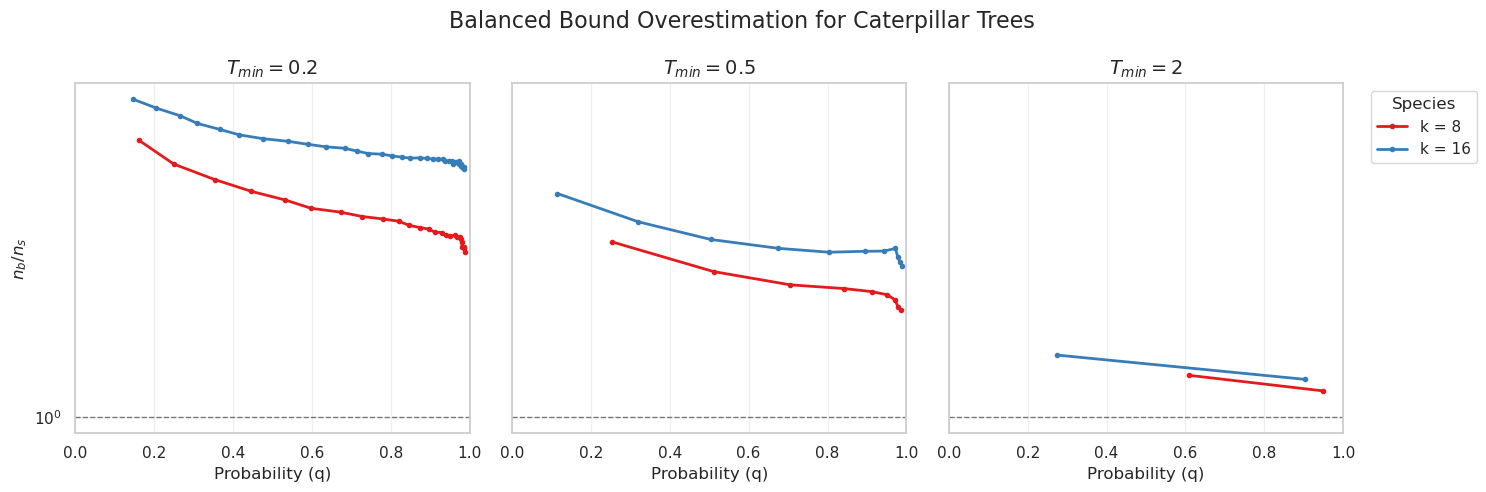

In [22]:
tree_name = 'Caterpillar'
species_tree_generator = create_caterpillar_tree
make_all_overestimation_plots(species_tree_generator, tree_name, 
                              k_vals, T_vals, q, 
                              all_bounds, names,
                              num_samples=num_samples, max_genes=max_genes, 
                              tolerance=tol)

##### Balanced Tree

In [23]:
bal_tree = create_balanced_tree(num_species, T_min)
print('Balanced Tree')
bal_tree.print_plot()

Balanced Tree
                                                  /------------------------- T0
                         /------------------------+                            
                         |                        \------------------------- T1
/------------------------+                                                     
|                        |                        /------------------------- T2
|                        \------------------------+                            
|                                                 \------------------------- T3
+                                                                              
|                                                 /------------------------- T4
|                        /------------------------+                            
|                        |                        \------------------------- T5
\------------------------+                                                     
                         |

T_min=2, k=16: 100%|██████████| 6/6 [00:02<00:00,  2.10it/s]  


################################################################################
Results for Original bound
################################################################################


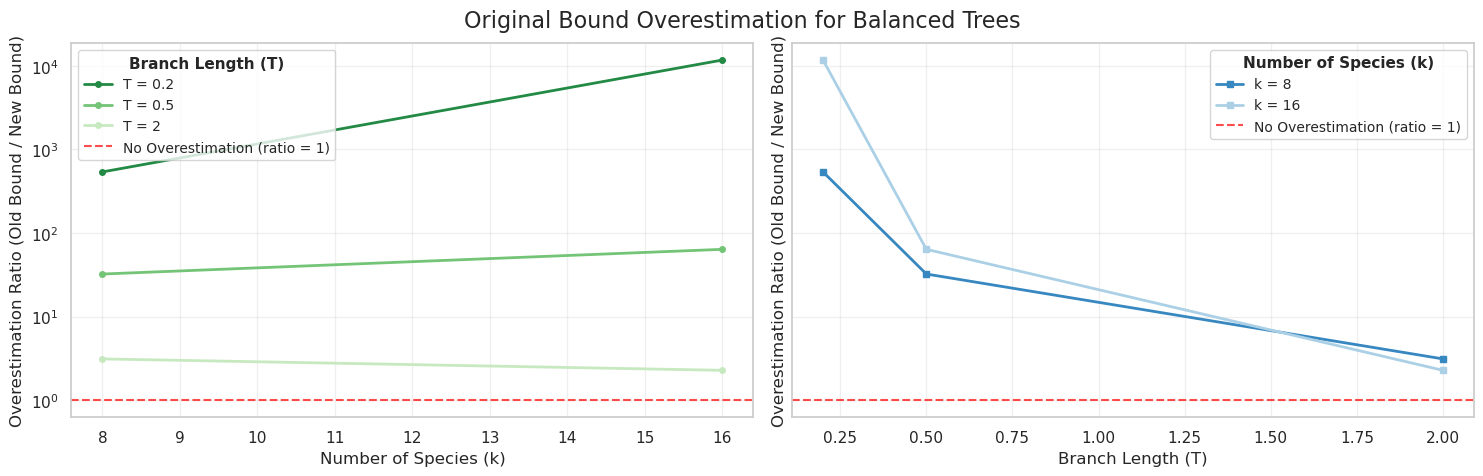

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_original_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_original_bound_vs_q.png


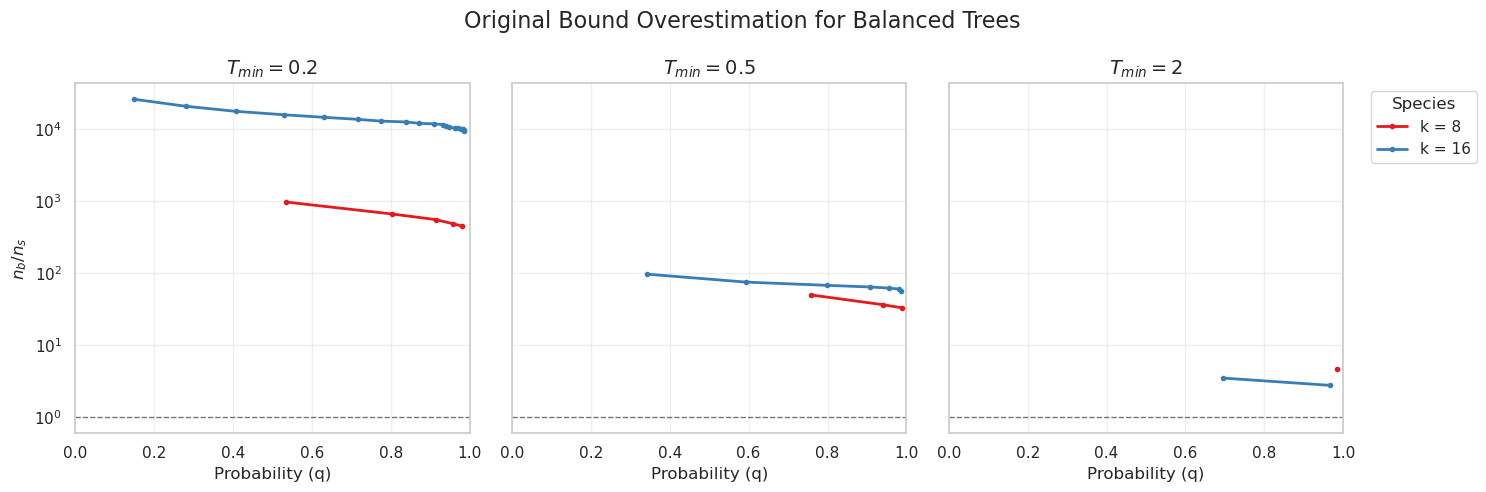

################################################################################
Results for Caterpillar bound
################################################################################


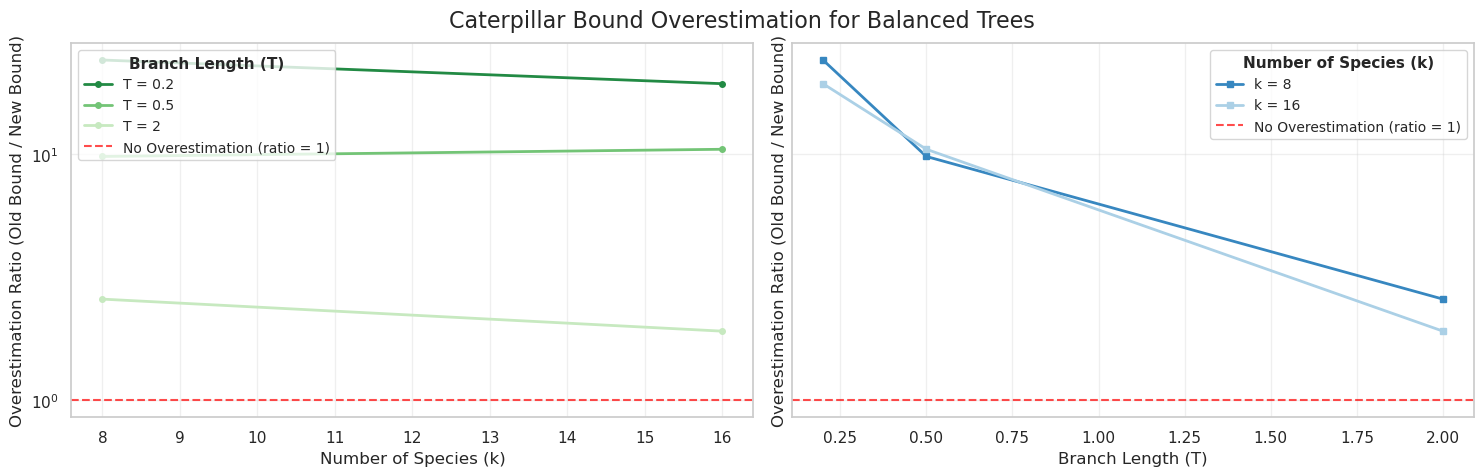

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_caterpillar_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_caterpillar_bound_vs_q.png


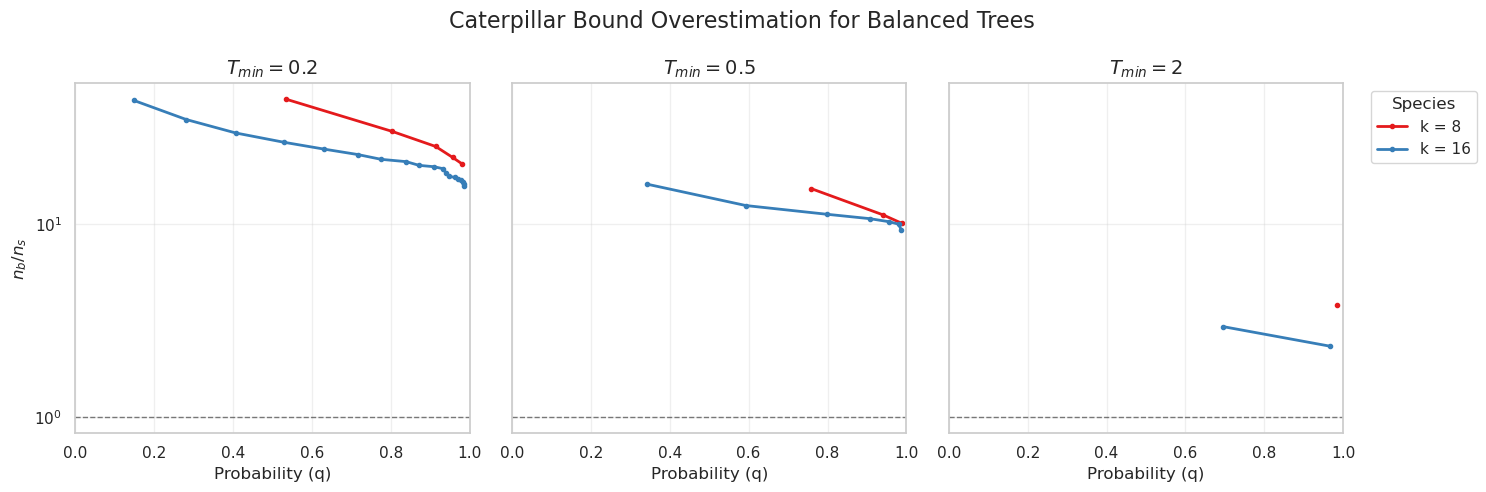

################################################################################
Results for Balanced bound
################################################################################


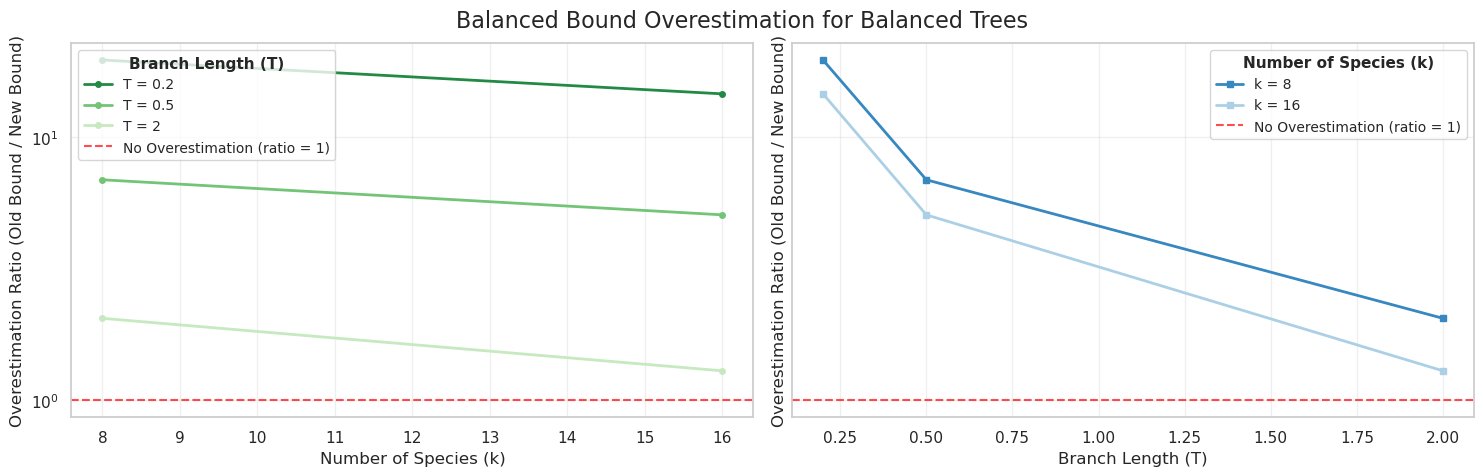

Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_balanced_bound_vs_T_k.png
Plot saved to: /usr/jovyan/bipartition_covers/figures/overestimation_ratios/balanced_tree_balanced_bound_vs_q.png


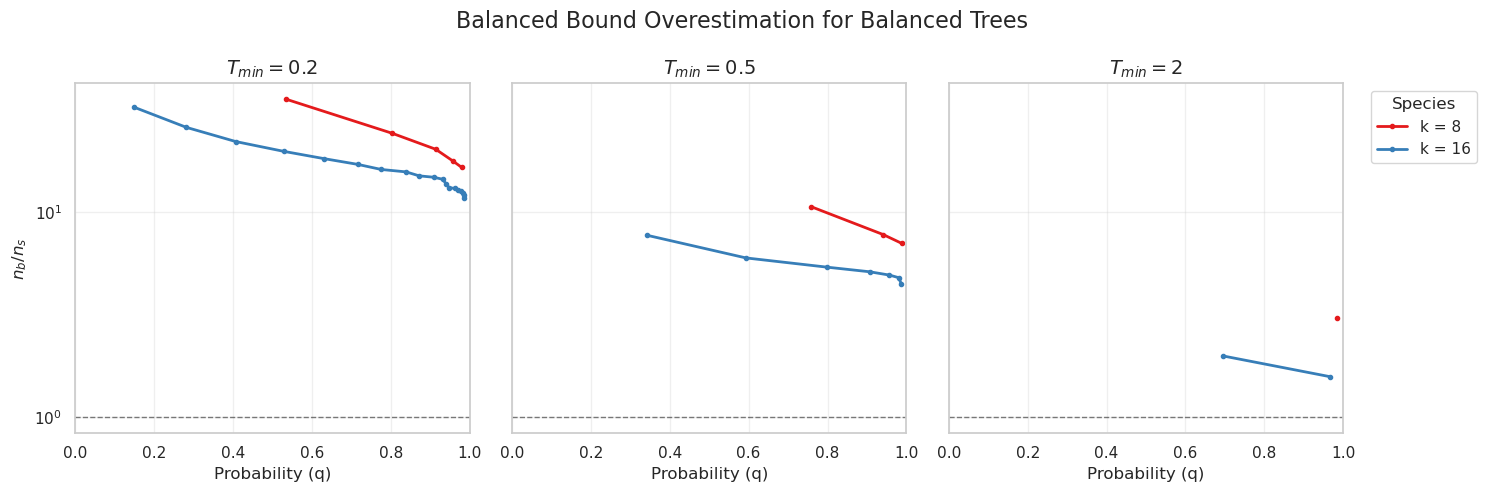

In [24]:
tree_name = 'Balanced'
species_tree_generator = create_balanced_tree
make_all_overestimation_plots(species_tree_generator, tree_name, 
                              k_vals, T_vals, q, 
                              all_bounds, names,
                              num_samples=num_samples, max_genes=max_genes, 
                              tolerance=tol)

### Yule Trees

The Yule model is a simple birth-death process (with no death; e.g. a pure birth process). To generate a species tree under the Yule model, we start with a single population. Then, each existing population splits in two at rate $\lambda$ where $\lambda$ is our birth-rate parameter. This continues until the desired number of species/populations/leaves are produced. Each internal branch in such a tree then has length $\exp(2\lambda)$. 

If we have $k$ species, since we have $k-2$ internal edges within our tree this means the minimum internal branch length is on the order $\frac{1}{2(k-2)\lambda}$.

A Yule tree in a sense represents more of a "typical" evolutionary tree we would expect.

In [25]:
birth_rate = 1
num_species = 20

# Generate species tree under Yule (birth-death) process
yule_tree = treesim.birth_death_tree(
    birth_rate=birth_rate, 
    death_rate=0.0, 
    num_extant_tips=num_species
)

# Find minimal length internal branch (exclude terminal/leaf branches)
T_min = get_T_min(yule_tree)
print('Minimal branch length: ', T_min) 

if num_species <= 20:
    yule_tree.print_plot()

Minimal branch length:  0.11342782812465704
                                                                /---------- T1 
                                                     /----------+              
                                          /----------+          \---------- T9 
                                          |          |                         
                                          |          \--------------------- T6 
/-----------------------------------------+                                    
|                                         |                     /---------- T3 
|                                         |          /----------+              
|                                         |          |          \---------- T15
|                                         \----------+                         
|                                                    |          /---------- T17
|                                                    \----------+           

For a Yule tree we want to get a sense of what the "typical" overestimation error looks like. To do so, we generate many Yule trees and plot the distribution of their overestimation ratios. As before, we do this for a range of different values of the minimum branch length and species count, parameters $T_{min}$ and $k$ respectively.

In [81]:
import importlib, utility
from utility.plotting import plot_overestimation_distribution

importlib.reload(utility.plotting)

<module 'utility.plotting' from '/usr/jovyan/bipartition_covers/utility/plotting.py'>

In [156]:
T_vals = [0.2, 0.5, 1]
k_vals = [8, 16]
birth_rate = 1
num_trees = 100
num_sample = 100
max_genes = 1000

result = plot_overestimation_distribution(T_vals, k_vals, q, 
                                 all_bounds, names,
                                 num_trees=num_trees, num_samples=num_samples, max_genes=max_genes, 
                                 birth_rate=birth_rate)

In [157]:
print(result.shape)
result.head()

(1800, 6)


,k,T_min,bound_name,theoretical,empirical,overestimation_ratio
0,8,0.2,Original,1616.205623,4.0,404.051406
1,8,0.2,Caterpillar,72.325295,4.0,18.081324
2,8,0.2,Balanced,58.697994,4.0,14.674498
3,8,0.2,Original,1616.205623,6.0,269.367604
4,8,0.2,Caterpillar,72.325295,6.0,12.054216


In [158]:
display(result.groupby(['T_min', 'k', 'bound_name'])['overestimation_ratio'].describe())

count          mean           std           min  \
T_min k  bound_name                                                     
0.2   8  Balanced     100.0     13.009565      9.157617      4.891499   
         Caterpillar  100.0     16.029861     11.283646      6.027108   
         Original     100.0    358.208715    252.148182    134.683802   
      16 Balanced     100.0     36.645773     23.434379     15.877937   
         Caterpillar  100.0     48.634820     31.101181     21.072571   
         Original     100.0  29576.986062  18914.004210  12815.162640   
0.5   8  Balanced     100.0      5.066574      2.559933      2.747352   
         Caterpillar  100.0      7.214043      3.644961      3.911817   
         Original     100.0     23.860483     12.055726     12.938355   
      16 Balanced     100.0      7.670917      2.224957      5.054791   
         Caterpillar  100.0     15.874091      4.604296     10.460315   
         Original     100.0     96.928224     28.114129     63.871361   
1.0   8  Balanced     100.0      2.621058      0.913508      1.617937   
         Caterpillar  100.0      3.652924      1.273141      2.254891   
         Original     100.0      5.957624      2.076390      3.677546   
      16 Balanced     100.0      3.338323      1.043861      2.240486   
         Caterpillar  100.0      6.327391      1.978513      4.246571   
         Original     100.0     10.949271      3.423730      7.348504   

                               25%           50%           75%            max  
T_min k  bound_name                                                            
0.2   8  Balanced         9.742905     11.739599     14.674498      58.697994  
         Caterpillar     12.004813     14.465059     18.081324      72.325295  
         Original       268.263638    323.241125    404.051406    1616.205623  
      16 Balanced        24.951045     34.931462     36.848433     174.657312  
         Caterpillar     33.114040     46.359656     48.903783     231.798278  
         Original     20138.112720  28193.357808  29740.554273  140966.789040  
0.5   8  Balanced         3.434190      4.578919      4.578919      13.736758  
         Caterpillar      4.889771      6.519695      6.519695      19.559086  
         Original        16.172944     21.563925     21.563925      64.691776  
      16 Balanced         6.318489      8.424651      8.424651      25.273954  
         Caterpillar     13.075394     17.433859     17.433859      52.301577  
         Original        79.839201    106.452268    106.452268     319.356803  
1.0   8  Balanced         2.426905      2.426905      2.426905       4.853810  
         Caterpillar      3.382337      3.382337      3.382337       6.764673  
         Original         5.516319      5.516319      5.516319      11.032637  
      16 Balanced         3.360728      3.360728      3.360728       6.721457  
         Caterpillar      6.369856      6.369856      6.369856      12.739713  
         Original        11.022756     11.022756     11.022756      22.045512

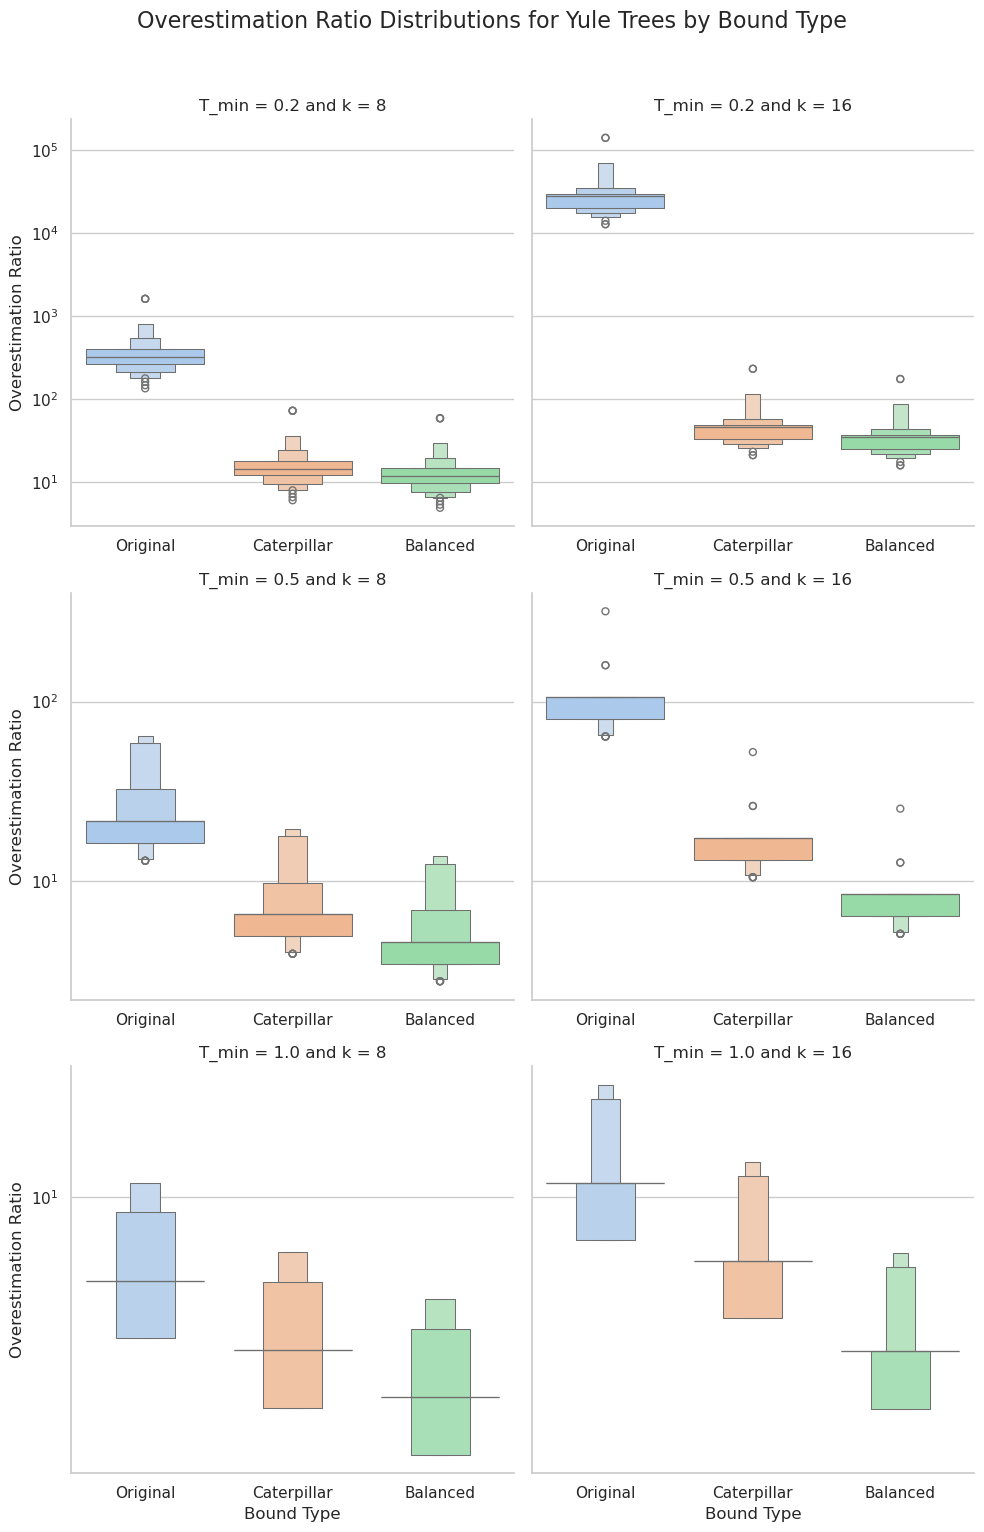

In [159]:
with sns.color_palette('pastel'):
    g = sns.catplot(data=result, kind='boxen',
                x='bound_name',
                y='overestimation_ratio', 
                col='k', 
                row='T_min',
                hue='bound_name',
                k_depth=4,
                legend=False,
                sharey='row',
                sharex=False)
    
    g.set(yscale='log')
    
    # Change axis labels
    g.set_axis_labels("Bound Type", "Overestimation Ratio")
    
    # Change the overall title
    g.fig.suptitle("Overestimation Ratio Distributions for Yule Trees by Bound Type", y=1.02, fontsize=16)
    
    # Optionally: Change individual facet titles
    g.set_titles("T_min = {row_name} and k = {col_name}")
    
    g.despine()
    
    # Optionally: Adjust layout to prevent title overlap
    plt.tight_layout()

    savepath = figures_dir / 'overestimation_ratios' / 'yule_trees_overestimation'
    plt.savefig(savepath, bbox_inches='tight')